# BEE-102-2025-Assignment-Aadish Jain-24321001

## Questions

1. [Normalized fragment length frequency](#1-normalized-fragment-length-frequency)
2. [Multi-line sequence fasta to single-line fasta file](#2-multi-line-sequence-fasta-to-single-line-fasta-file)
3. [Building Markov transition matrix](#3-building-markov-transition-matrix)
4. [V-plot](#4-v-plot)
5. [Writing codes for linear regression](#5-writing-codes-for-linear-regression)
6. [Reading a PDB file to output protein sequence](#6-reading-a-pdb-file-to-output-protein-sequence)

### 1. Normalized fragment length frequency

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


file = 'sequence.bed.gz' 

import gzip
df = pd.read_csv(
    gzip.open(file, 'rt'),
    sep='\t',
    header=None,
    usecols=[0, 1, 2],
    names=['chrom', 'start', 'end']
)


df.head()

,chrom,start,end
0,chr10,32795245,32795315
1,chr11,95864728,95864770
2,chr16,32027808,32027880
3,chr4,76608451,76608515
4,chr18,45847777,45847816


In [2]:
df['length'] = df['end'] - df['start']

df[['chrom', 'start', 'end', 'length']].head()

,chrom,start,end,length
0,chr10,32795245,32795315,70
1,chr11,95864728,95864770,42
2,chr16,32027808,32027880,72
3,chr4,76608451,76608515,64
4,chr18,45847777,45847816,39


In [3]:
freq = df['length'].value_counts().sort_index()

normalized_freq = freq / freq.sum()

normalized_freq.head()

length
24    0.000026
25    0.000116
26    0.000156
27    0.000184
28    0.000213
Name: count, dtype: float64

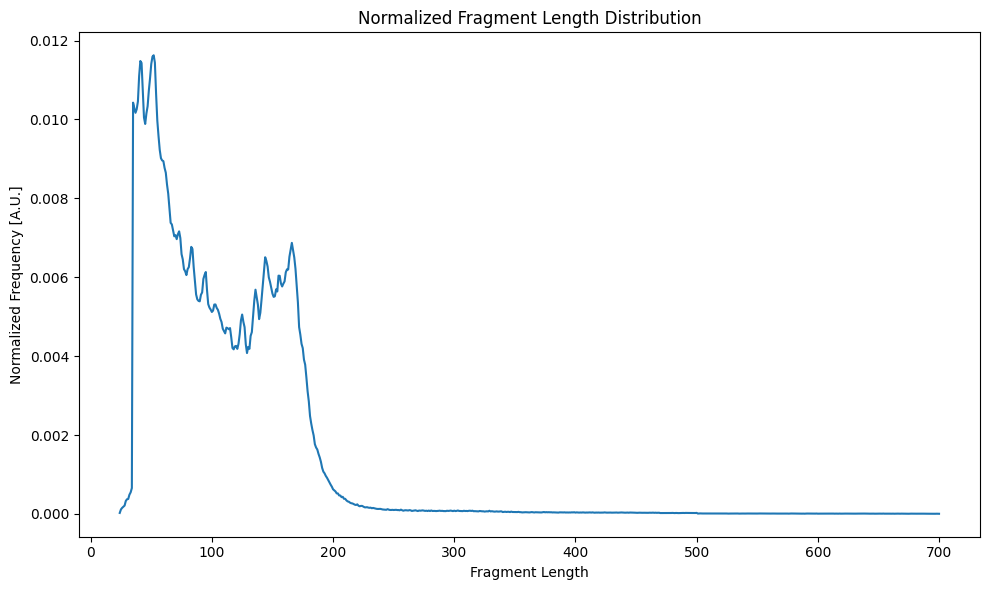

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(normalized_freq.index, normalized_freq.values)
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Normalized Fragment Length Distribution')
plt.tight_layout()
plt.show()

### 2. Multi-line sequence fasta to single-line fasta file

In [5]:
with open('multiline_input.fasta', 'r') as infile, open('new_sequence.fasta', 'w') as outfile:
    seq = ''
    for line in infile:
        line = line.strip()
        if line[0] == '>':
            if seq:
                outfile.write(seq + '\n')
            outfile.write(line + '\n')
            seq = ''
        else:
            seq += line
    if seq:
        outfile.write(seq + '\n')

### 3. Building Markov transition matrix

In [6]:
sequence = "TCCAATTGAGCTATACCGTCAGAAGTAGATGAGATCTAACGG"
nucleotides = ['A', 'C', 'G', 'T']

mat = {i: {j: 0 for j in nucleotides} for i in nucleotides}

for i in range(len(sequence) - 1):
    mat[sequence[i]][sequence[i + 1]] += 1

for nucleo1 in nucleotides:
    total = sum(mat[nucleo1].values())
    for nucleo2 in nucleotides:
        if total != 0:
            mat[nucleo1][nucleo2] /= total
        else:
            mat[nucleo1][nucleo2] = 0
print("Markov Transition Matrix")
print("    A    C    G     T")
for nucleo in nucleotides:
    print(f"{nucleo}:",*[f"{value:.2f}" for value in mat[nucleo].values()])


Markov Transition Matrix
    A    C    G     T
A: 0.21 0.14 0.36 0.29
C: 0.25 0.25 0.25 0.25
G: 0.56 0.11 0.11 0.22
T: 0.40 0.30 0.20 0.10


### 4. V-plot

In [7]:
import gzip
import numpy as np

Xs, Ys = [], []
with gzip.open("mapped.bed.gz", "rt") as fh:
    for line in fh:
        cols = line.split("\t")
        s1, e1 = int(cols[2]), int(cols[3])
        s2, e2 = int(cols[8]), int(cols[9])
        center1 = 0.5*(s1+e1)
        center2 = 0.5*(s2+e2)
        Xs.append(center2 - center1)
        Ys.append(e2 - s2)

Xs = np.array(Xs)
Ys = np.array(Ys)
print("Processed", len(Xs), "fragments")
print("X range:", Xs.min(), "to", Xs.max())
print("Y range:", Ys.min(), "to", Ys.max())


Processed 4336134 fragments
X range: -509.0 to 509.5
Y range: 40 to 500


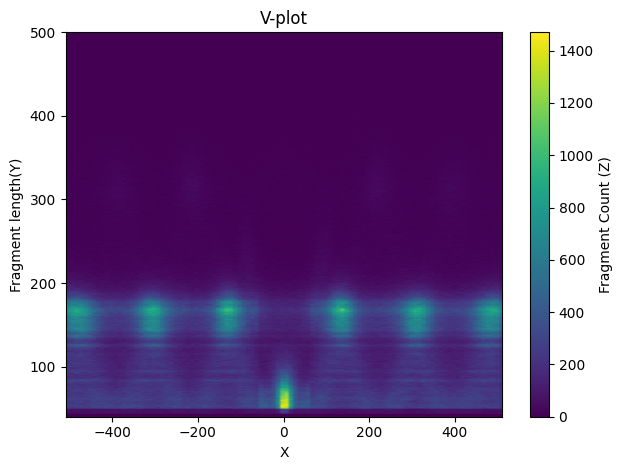

In [8]:
bin_size_x = 10
bin_size_y = 1 

x_bins = np.arange(Xs.min(), Xs.max() + bin_size_x, bin_size_x)
y_bins = np.arange(Ys.min(), Ys.max() + bin_size_y, bin_size_y)

Z, y_edges, x_edges = np.histogram2d(
    Ys,
    Xs,
    bins=[y_bins, x_bins]
)

plt.imshow(
    Z,
    aspect='auto',
    origin='lower',
    extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]),
    cmap="viridis"
)
plt.colorbar(label="Fragment Count (Z)")
plt.xlabel("X")
plt.ylabel("Fragment length(Y)")
plt.title("V-plot")
plt.tight_layout()
plt.show()

### 5. Writing codes for linear regression

I had created a data that roughly follows the line -> y = 2x + 5

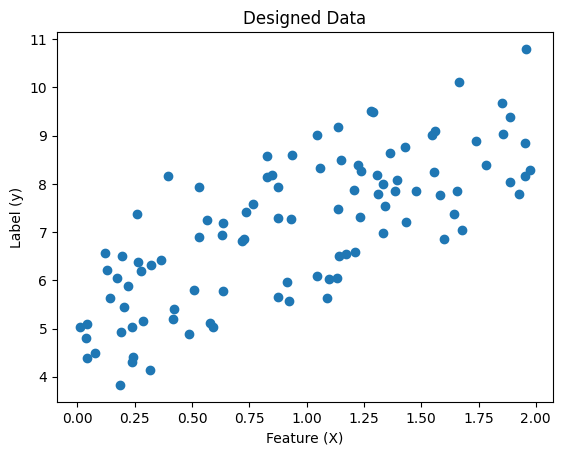

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 5 + 2 * X + np.random.randn(100, 1) 

plt.scatter(X, y)
plt.xlabel("Feature (X)")
plt.ylabel("Label (y)")
plt.title("Designed Data")
plt.show()


In [10]:
def cost_compute(X, y, w, b):
    m = X.shape[0]
    cost = 0
    for i in range(m):
        cost += float((w * X[i] + b - y[i]) ** 2)
    cost /= (2 * m)
    return cost

In [11]:
def gradient(X, y, w, b):
    m = X.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        dj_dw += (w * X[i] + b - y[i]) * X[i]
        dj_db += (w * X[i] + b - y[i])
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [12]:
def gradient_descent(X, y, w, b, alpha, iteration):
    m = X.shape[0]

    for _ in range(iteration):
        dj_dw, dj_db = gradient(X, y, w, b)
        w = float(w - alpha * dj_dw)
        b = float(b - alpha * dj_db)
    
    return w, b

In [13]:
initial_w = 2
initial_b = 1
alpha = 0.1
iteration = 1000
w, b = gradient_descent(X, y, initial_w, initial_b, alpha, iteration)
print(f"w, b: {w:.3f} {b:.3f}")

C:\Users\AADISH\AppData\Local\Temp\ipykernel_17132\3871670781.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w = float(w - alpha * dj_dw)
C:\Users\AADISH\AppData\Local\Temp\ipykernel_17132\3871670781.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b = float(b - alpha * dj_db)


w, b: 1.968 5.222


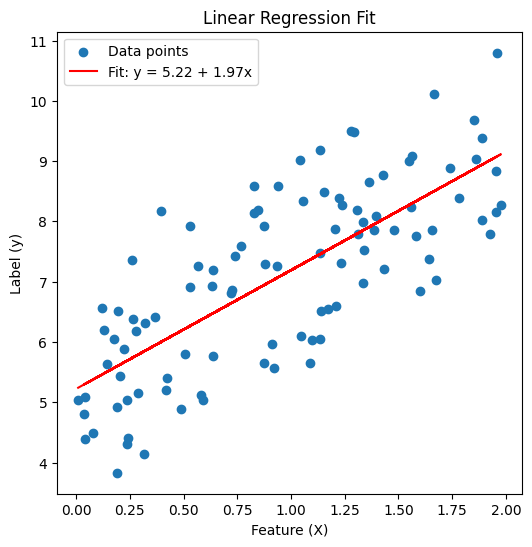

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(X, y, label="Data points")
plt.plot(X, w * X + b, color="red", label=f"Fit: y = {b:.2f} + {w:.2f}x")
plt.xlabel("Feature (X)")
plt.ylabel("Label (y)")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

**Variance Decomposition**

- **Total Sum of Squares (TSS)** measures the overall variance in the data:

  $$\displaystyle TSS = \sum_{i}(y_i - \bar y)^2$$

- **Explained Sum of Squares (ESS)** is the variance captured by our model:

  $$\displaystyle ESS = \sum_{i}(\hat y_i - \bar y)^2$$

- **Residual Sum of Squares (RSS)** is the variance left over (errors):

  $$\displaystyle RSS = \sum_{i}(y_i - \hat y_i)^2$$

They satisfy:

$$
TSS = ESS + RSS
$$


**Computing TSS, ESS, RSS:**

In [15]:
y_pred = w * X + b

y_mean = np.mean(y)

TSS = np.sum((y - y_mean) ** 2)

ESS = np.sum((y_pred - y_mean) ** 2)

RSS = np.sum((y - y_pred) ** 2)

print(f"TSS = {TSS:.4f}")
print(f"ESS = {ESS:.4f}")
print(f"RSS = {RSS:.4f}")

TSS = 228.0720
ESS = 128.8281
RSS = 99.2439


### 6. Reading a PDB file to output protein sequence

In [16]:
three_to_one = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

chain_sequences = {}

with open("2r5z.pdb", "r") as pdb_file:
    for line in pdb_file:
        if line.startswith("SEQRES"):
            chain_id = line[11].strip()
            residues = line[19:].split()
            valid_residues = [three_to_one.get(res.upper()) for res in residues if res.upper() in three_to_one]
            if valid_residues:
                if chain_id not in chain_sequences:
                    chain_sequences[chain_id] = []
                chain_sequences[chain_id].extend(valid_residues)

for chain_id, sequence in sorted(chain_sequences.items()):
    print(f">2R5Z_chain{chain_id}")
    print("".join(sequence))


>2R5Z_chainA
GKKNPPQIYPWMKRVHLGTSTVNANGETKRQRTSYTRYQTLELEKEFHFNRYLTRRRRIEIAHALSLTERQIKIWFQNRRMKWKKEHK
>2R5Z_chainB
ARRKRRNFSKQASEILNEYFYSHLSNPYPSEEAKEELARKCGITVSQVSNWFGNKRIRYKKNI
